In [1]:
clc;
clear;
close all;

fs = 2000;
t = 0:1/fs:1;

x = sin(2*pi*5*t)

x = 1x2001    
         0    0.0157    0.0314    0.0471    0.0628    0.0785    0.0941    0.1097    0.1253    0.1409    0.1564    0.1719    0.1874    0.2028    0.2181    0.2334    0.2487    0.2639    0.2790    0.2940    0.3090    0.3239    0.3387    0.3535    0.3681    0.3827    0.3971    0.4115    0.4258    0.4399    0.4540    0.4679    0.4818    0.4955    0.5090    0.5225    0.5358    0.5490    0.5621    0.5750    0.5878    0.6004    0.6129    0.6252    0.6374    0.6494    0.6613    0.6730    0.6845    0.6959

In [2]:

bits = 3;
L = 2^bits;

xmin = -1;
xmax = 1;

delta = (xmax-xmin)/L

delta = 0.2500

In [3]:
x1 = round((x-xmin)/delta)

x1 = 1x2001    
     4     4     4     4     4     4     4     4     5     5     5     5     5     5     5     5     5     5     5     5     5     5     5     5     5     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     6     7     7     7     7     7     7     7


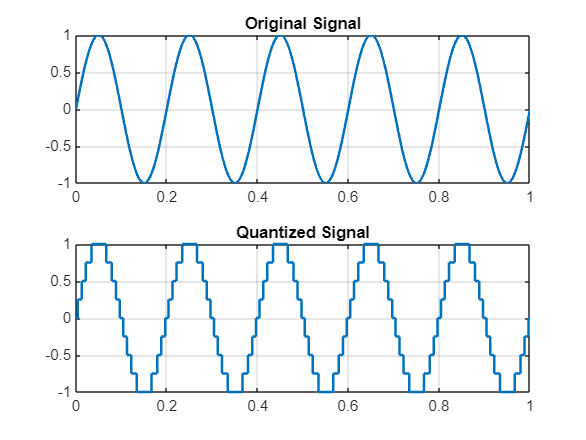

In [4]:
xq = round((x-xmin)/delta)*delta + xmin;

figure;

subplot(2,1,1)
plot(t,x,'LineWidth',1.5)
title('Original Signal')
grid on

subplot(2,1,2)
stairs(t,xq,'LineWidth',1.5)
title('Quantized Signal')
grid on

In [5]:
clc;
clear;
close all;

fs = 2000;              % Sampling frequency
t = 0:1/fs:1;           % Time vector
x = sin(2*pi*5*t);      % Original sine signal

bits = 3;               % Number of quantization bits
L = 2^bits;             % Number of quantization levels

xmin = -1;              % Minimum quantizer range
xmax = 1;               % Maximum quantizer range

delta = (xmax - xmin) / L;   % Step size

% --- Quantization step by step ---
% Step 1: Shift by xmin
shifted = x - xmin;

% Step 2: Scale by delta
scaled = shifted / delta;

% Step 3: Round to nearest integer
indices = round(scaled);

% Step 4: Multiply back by delta
rescaled = indices * delta;

% Step 5: Shift back by xmin
xq = rescaled + xmin;

% --- Show first few calculations ---
disp('First 10 samples step-by-step:')

First 10 samples step-by-step:

In [6]:
for i = 1:10
    fprintf('x=%.3f | shifted=%.3f | scaled=%.3f | index=%d | rescaled=%.3f | xq=%.3f\n', ...
        x(i), shifted(i), scaled(i), indices(i), rescaled(i), xq(i));
end

x=0.000 | shifted=1.000 | scaled=4.000 | index=4 | rescaled=1.000 | xq=0.000
x=0.016 | shifted=1.016 | scaled=4.063 | index=4 | rescaled=1.000 | xq=0.000
x=0.031 | shifted=1.031 | scaled=4.126 | index=4 | rescaled=1.000 | xq=0.000
x=0.047 | shifted=1.047 | scaled=4.188 | index=4 | rescaled=1.000 | xq=0.000
x=0.063 | shifted=1.063 | scaled=4.251 | index=4 | rescaled=1.000 | xq=0.000
x=0.078 | shifted=1.078 | scaled=4.314 | index=4 | rescaled=1.000 | xq=0.000
x=0.094 | shifted=1.094 | scaled=4.376 | index=4 | rescaled=1.000 | xq=0.000
x=0.110 | shifted=1.110 | scaled=4.439 | index=4 | rescaled=1.000 | xq=0.000
x=0.125 | shifted=1.125 | scaled=4.501 | index=5 | rescaled=1.250 | xq=0.250
x=0.141 | shifted=1.141 | scaled=4.564 | index=5 | rescaled=1.250 | xq=0.250

In [7]:
clc;clear;close all;


## read audio

In [8]:
[m, fs] = audioread("audio2.aac");

msg = m(:, 1);
msg = msg/max(abs(msg));  % to make it in range of 1 to -1 for quantization
N = length(msg);
t = (0: N-1)/fs

t = 1x339555    
         0    0.0000    0.0000    0.0001    0.0001    0.0001    0.0001    0.0001    0.0002    0.0002    0.0002    0.0002    0.0003    0.0003    0.0003    0.0003    0.0003    0.0004    0.0004    0.0004    0.0004    0.0004    0.0005    0.0005    0.0005    0.0005    0.0005    0.0006    0.0006    0.0006    0.0006    0.0006    0.0007    0.0007    0.0007    0.0007    0.0008    0.0008    0.0008    0.0008    0.0008    0.0009    0.0009    0.0009    0.0009    0.0009    0.0010    0.0010    0.0010    0.0010


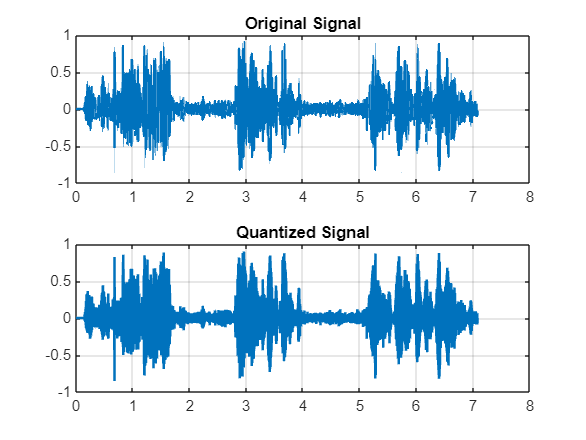

In [9]:

figure;

bits = 16;
L = 2^bits;

xmax = 1;
xmin = -1;

delta = (xmax-xmin)/L;

xq = round((msg-xmin)/delta)*delta + xmin;

figure;

subplot(2,1,1)
plot(t,msg,'LineWidth',1.5)
title('Original Signal')
grid on

subplot(2,1,2)
stairs(t,xq,'LineWidth',1.5)
title('Quantized Signal')
grid on

In [10]:
sound(xq ,fs)


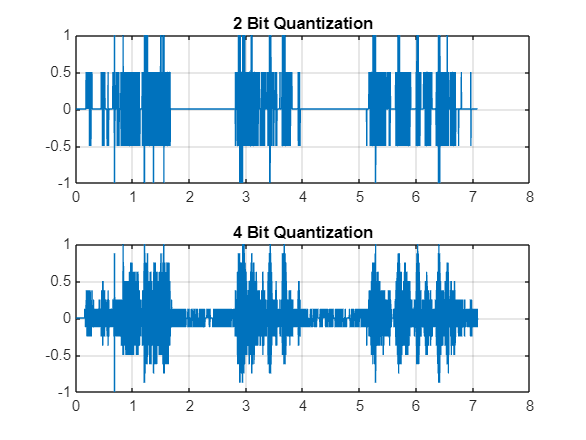

In [11]:
clc;
clear;
close all;

%% Read Audio

[m,fs] = audioread("audio2.aac");

msg = m(:,1);

msg = msg/max(abs(msg));

bits = [2 4 8 16 32];

figure

for k=1:length(bits)

    b = bits(k);

    L = 2^b;

    xmin = -1;
    xmax = 1;

    delta = (xmax-xmin)/L;

    q = round((msg-xmin)/delta)*delta + xmin;

    t = (0:length(q)-1)/fs;

    subplot(length(bits),1,k)

    plot(t,q)

    title([num2str(b),' Bit Quantization'])

    grid on

end

In [12]:

%% Listen

for k=1:length(bits)

    b = bits(k);

    L = 2^b;

    xmin = -1;
    xmax = 1;

    delta = (xmax-xmin)/L;

    q = round((msg-xmin)/delta)*delta + xmin;

    fprintf("\nPlaying %d-bit Quantized Voice\n",b);

    sound(q,fs);

    pause(length(q)/fs+2)

end

Playing 2-bit Quantized Voice
Playing 4-bit Quantized Voice

In [13]:
clc;
clear;
close all;

[m,fs] = audioread("audio2.aac");

msg = m(:,1);

msg = msg/max(abs(msg));

bits = 3;

L = 2^bits;

xmin = -1;
xmax = 1;

delta = (xmax-xmin)/L;

q = round((msg-xmin)/delta)*delta + xmin;

error = msg - q;

t = (0:length(msg)-1)/fs;

figure

subplot(3,1,1)
plot(t,msg)
title('Original Voice')
grid on

subplot(3,1,2)
plot(t,q)
title('Quantized Voice')
grid on

subplot(3,1,3)
plot(t,error)
title('Quantization Error')
grid on